# 변수에 대한 가설 검증

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 기호 깨짐 방지


# 통계 코드 가져오기
from stat_utils import anova_test, numerical_test, chi_square, statistical_tests_step2, pearsonr, spearmanr, kruskal

pd.options.display.float_format = '{:,.2f}'.format

df = pd.read_csv("artifacts/train_data.csv")

### 가설 1 : 한도소진율 그룹 별 '잔액_리볼빙일시불이월_B0M' 차이

### 가설 내용
- 한도소진율이 높을수록 신용한도 여유가 줄어들어 현금 흐름 압박 및 리볼빙 이용 가능성이 커질 수 있다.
- 그래서 한도소진율을 저/중/고소진 그룹으로 나눠 리볼빙 잔액에 차이가 있는지 통계적으로 확인
    - 한도 소진 그룹을 50%와 80%로 구분한 이유 

        : 내가 가진 한도의 50% 이하를 사용했다는 것 = 절반 이하를 사용 -> 저소진 그룹 = 여유 그룹 / 안정 구간

        ,                                                             중간 그룹 = 관찰 구간

        , 내가 가진 한도의 80% 이상을 사용했다는 것 = 4/5 이상을 사용 -> 고소진 그룹 = 한도에 타이트한 그룹 / 경고 구간

### 검증 방법

- 각 집단의 평균을 계산해서 세 집단의 평균값의 차이가 유의미하게 있는지 확인

In [3]:
COL_UTIL = "잔액_신판평균한도소진율_r6m"
COL_Y    = "잔액_리볼빙일시불이월_B0M"

# (1) 한도소진율 기준으로 3개 그룹 나누기
bins = [0, 0.5, 0.8, 1.5]
labels = ['저소진(≤50%)', '중간소진(50~80%)', '고소진(>80%)']

df_tmp = df[[COL_UTIL, COL_Y]].dropna().copy()
df_tmp["util_group"] = pd.cut(
    df_tmp[COL_UTIL],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# 그룹 평균 차이 검정 
f_stat, p_value = anova_test(df_tmp, target_column="util_group", var=COL_Y)
print("ANOVA f_stat:", f_stat, "p_value:", p_value)


print(df_tmp.groupby("util_group")[COL_Y].agg(["count","mean","median"]).round(2))


ANOVA f_stat: 7773.92425824263 p_value: 0.0
              count         mean       median
util_group                                   
저소진(≤50%)     34831 1,093,416.63 1,078,508.00
중간소진(50~80%)  40411 1,393,797.35 1,403,173.00
고소진(>80%)      8161 1,533,565.14 1,529,936.00


C:\Users\jongy\AppData\Local\Temp\ipykernel_19672\18868077.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_tmp.groupby("util_group")[COL_Y].agg(["count","mean","median"]).round(2))


### 결과
- ANOVA 결과 p-value가 0.0으로 유의수준 0.05에서 귀무가설(세 집단의 평균이 동일하다.)를 기각
- 즉, 적어도 한 그룹의 평균은 다르다.

### 설명용 그림

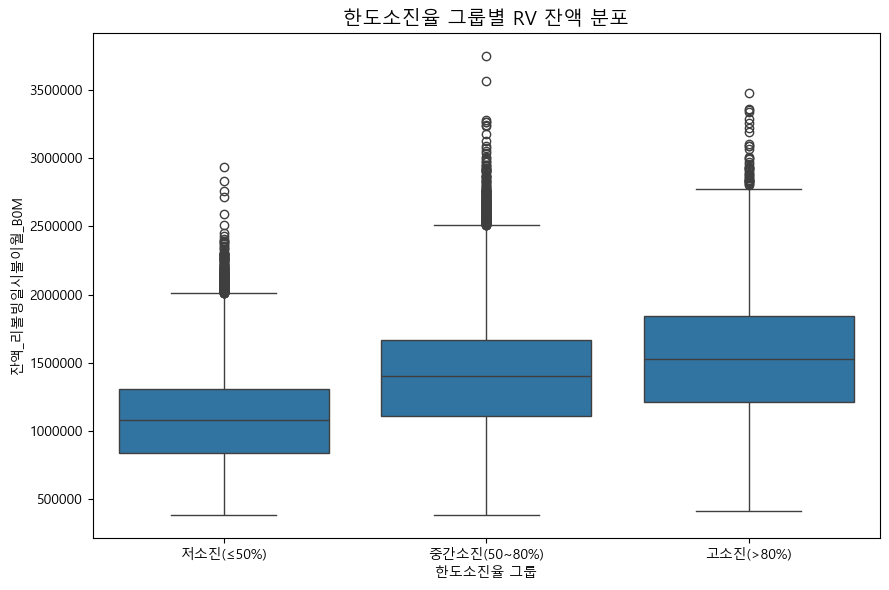

In [4]:
plt.figure(figsize=(9, 6))
sns.boxplot(
    data=df_tmp,
    x="util_group",
    y=COL_Y,
    showfliers=True   # 이상치 제거 (발표용으로 깔끔)
)

plt.title("한도소진율 그룹별 RV 잔액 분포", fontsize=14)
plt.xlabel("한도소진율 그룹")
plt.ylabel("잔액_리볼빙일시불이월_B0M")
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

-----------------------------------------------------------------------------------------------------------------------------------------------

### 가설 2 : 한도소진율 - 잔액_리볼빙 관계

### 가설 내용

- 한계소진율이 커질수록 잔액_리볼빙이 커지는 관계를 가지고 있나?
    - Pearson : 가설의 관계가 선형적인가?  Spearman : 증가 / 감소 방향 확인

### 검증 방법

- 한도소진율과 잔액_리볼빙 간의 상관분석을 진행

In [5]:
COL_UTIL = "잔액_신판평균한도소진율_r6m"
COL_Y    = "잔액_리볼빙일시불이월_B0M"


df_tmp1 = df[[COL_UTIL, COL_Y]].dropna().copy()

output, relevant_cols = statistical_tests_step2(
    df=df_tmp1,
    target_column=COL_Y,
    analysis_columns=[COL_UTIL],
    significance_level=0.05,
    abs_corr_threshold=0.0  
)

result = output[COL_UTIL]

print("Pearson r:", result["pearson_corr"])
print("Pearson p-value:", result["pearson_p"])
print("Spearman rho:", result["spearman_corr"])
print("Spearman p-value:", result["spearman_p"])


Relevant : 잔액_신판평균한도소진율_r6m (Pearson r=0.4573, Spearman ρ=0.4494, abs_corr_threshold=0.0)
Pearson r: 0.45730460459131383
Pearson p-value: 0.0
Spearman rho: 0.44938589190861294
Spearman p-value: 0.0


### 결과
- Pearson과 Spearman의 p-value가 0에 근접하므로 유의수준 0.05에서 귀무가설(상관계수=0)을 기각
- 즉, 두 변수 간의 상관계수는 0이 아니다. 두 변수 모두 약 0.4의 값을 가지므로 중간 정도의 양의 상관관계를 가진다고 볼 수 있다.

### 설명용 그림

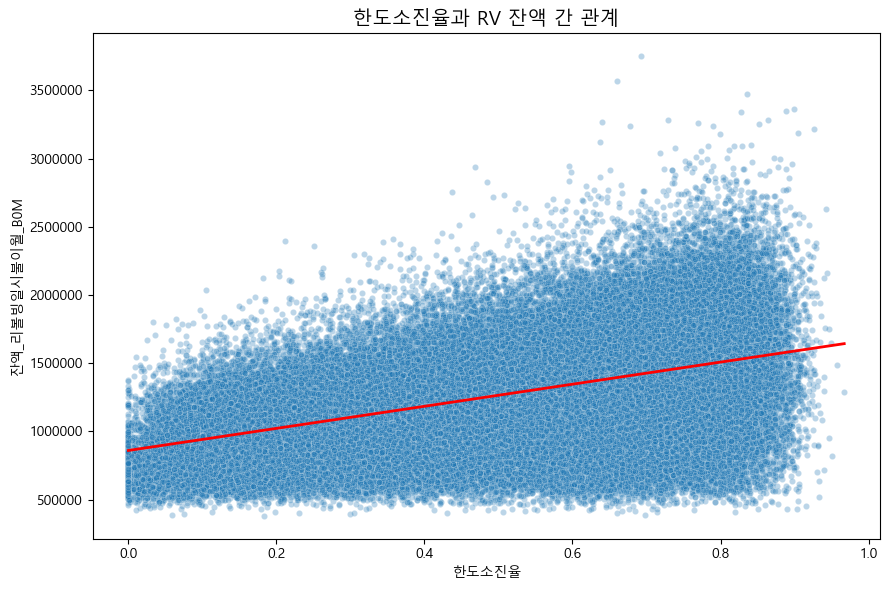

In [6]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_tmp1,
    x=COL_UTIL,
    y=COL_Y,
    alpha=0.3,          # 점 겹침 완화
    s=20
)

# 선형 추세선 (Pearson 시각화)
sns.regplot(
    data=df_tmp1,
    x=COL_UTIL,
    y=COL_Y,
    scatter=False,
    color="red",
    line_kws={"linewidth": 2}
)

plt.title("한도소진율과 RV 잔액 간 관계", fontsize=14)
plt.xlabel("한도소진율")
plt.ylabel("잔액_리볼빙일시불이월_B0M")

# y축 지수표기 제거
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()


### *동일한 한도소진율에서도 RV잔액 분산이 큼 

In [18]:
pd.options.display.float_format = '{:,.2f}'.format

stats = df_tmp.groupby("util_group")[COL_Y].agg(
    count="count",
    mean="mean",
    std=lambda s: s.std(ddof=1),
    var=lambda s: s.var(ddof=1),
    cv=lambda s: s.std(ddof=1)/s.mean()
)

display(stats)

C:\Users\jongy\AppData\Local\Temp\ipykernel_19672\2748425449.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_tmp.groupby("util_group")[COL_Y].agg(


,count,mean,std,var,cv
util_group,,,,,
저소진(≤50%),34831,"1,093,416.63","322,724.43","104,151,057,054.02",0.30
중간소진(50~80%),40411,"1,393,797.35","409,327.30","167,548,839,012.34",0.29
고소진(>80%),8161,"1,533,565.14","459,920.14","211,526,537,719.03",0.30


한도소진율이 RV잔액의 방향성은 설명하나, 동일한 소진율일 때 고객들의 RV 금액 차이를 설명하지 못함. 그래서 'RV잔액x한도소진율'이라는 파생 변수 생성

,     - 고객의 한도소진율을 기준으로 RV잔액의 상대적인 규모를 파악. ->  파생변수를 통해RV 위험 노출의 상대적 크기를 명확히 표현할 수 있다.
    
,     ex. 한도소진율이 0.2이지만 RV잔액이 100만원인 고객과 한도소진율이 0.5이지만 RV잔액이 40만원인 고객의 상대적 규모는 동일하다고 볼 수 있다.

### 새로 만든 파생 변수로 상관분석과 Scatterplot을 다시 진행

In [19]:
df['RV잔액x한도소진율'] = (df['잔액_리볼빙일시불이월_B0M'] * df['잔액_신판평균한도소진율_r6m'])


COL_UTIL2 = "RV잔액x한도소진율"
COL_Y    = "잔액_리볼빙일시불이월_B0M"


df_tmp2 = df[[COL_UTIL2, COL_Y]].dropna().copy()


output, relevant_cols = statistical_tests_step2(
    df=df_tmp2,
    target_column=COL_Y,
    analysis_columns=[COL_UTIL2],   
    significance_level=0.05,
    abs_corr_threshold=0.0 

)

result2 = output[COL_UTIL2]

print("Pearson r:", result2["pearson_corr"])
print("Pearson p-value:", result2["pearson_p"])
print("Spearman rho:", result2["spearman_corr"])
print("Spearman p-value:", result2 ["spearman_p"])



Relevant : RV잔액x한도소진율 (Pearson r=0.8277, Spearman ρ=0.8011, abs_corr_threshold=0.0)
Pearson r: 0.8277366895581919
Pearson p-value: 0.0
Spearman rho: 0.8010533278360744
Spearman p-value: 0.0


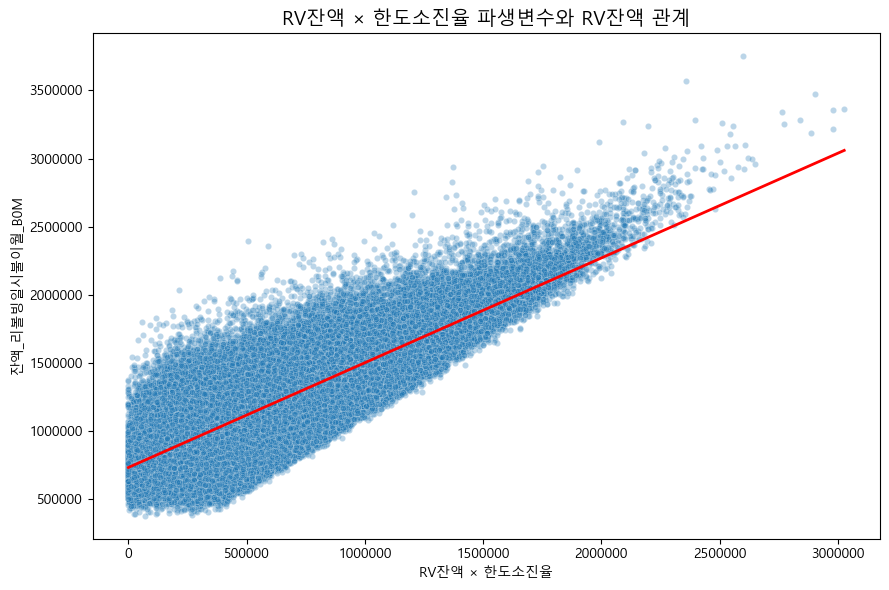

In [20]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_tmp2,
    x=COL_UTIL2,
    y=COL_Y,
    alpha=0.3,
    s=20
)

# 추세선
sns.regplot(
    data=df_tmp2,
    x=COL_UTIL2,
    y=COL_Y,
    scatter=False,
    color="red",
    line_kws={"linewidth": 2}
)

plt.title("RV잔액 × 한도소진율 파생변수와 RV잔액 관계", fontsize=14)
plt.xlabel("RV잔액 × 한도소진율")
plt.ylabel("잔액_리볼빙일시불이월_B0M")

plt.ticklabel_format(style='plain', axis='both')
plt.tight_layout()
plt.show()

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### 가설 3 : 이용금액_신용 - 잔액_리볼빙 관계

### 가설 내용
- 신용 이용 금액이 클수록 현금에 여유가 없다고 판단할 수 있다.
- 현금에 여유가 없으니 자연스레 RV 사용으로 이어질 가능성이 있다.
- 따라서 이용금액_신용이 클수록 RV 잔액이 커질 수 있다.

### 검증 방법
- 이용금액_신용_B0M과 잔액_리볼빙 간의 상관분석을 진행

In [22]:
COL_X = "이용금액_신용_B0M"
COL_Y = "잔액_리볼빙일시불이월_B0M"   # 네가 앞에서 쓰던 Y

# 결측 제거 + 혹시 문자열 섞였으면 숫자로 변환(안 되면 NaN)
df_tmp = df[[COL_X, COL_Y]].copy()
df_tmp[COL_X] = pd.to_numeric(df_tmp[COL_X], errors="coerce")
df_tmp[COL_Y] = pd.to_numeric(df_tmp[COL_Y], errors="coerce")
df_tmp = df_tmp.dropna()

output, relevant_cols = statistical_tests_step2(
    df=df_tmp,
    target_column=COL_Y,
    analysis_columns=[COL_X],
    significance_level=0.05,
    abs_corr_threshold=0.0
)

result = output[COL_X]

print("Pearson r:", result["pearson_corr"])
print("Pearson p-value:", result["pearson_p"])
print("Spearman rho:", result["spearman_corr"])
print("Spearman p-value:", result["spearman_p"])


Relevant : 이용금액_신용_B0M (Pearson r=0.0872, Spearman ρ=0.1520, abs_corr_threshold=0.0)
Pearson r: 0.08720396686287017
Pearson p-value: 1.7926283700936872e-140
Spearman rho: 0.1519925028174119
Spearman p-value: 0.0


### 결과
- Pearson과 Spearman의 p-value가 0에 근접하므로 귀무가설(상관계수=0)을 기각
- 즉, 두 변수 간의 상관계수는 0이 아니다.
- 하지만 유의미한 상관관계가 있다고 보기에는 Pearson 값과 Spearman의 값이 매우 작게 나타난다.

   통계적으로는 유의미하지만, 실질적인 상관관계는 거의 없는 것으로 판단된다.

### 설명용 그림

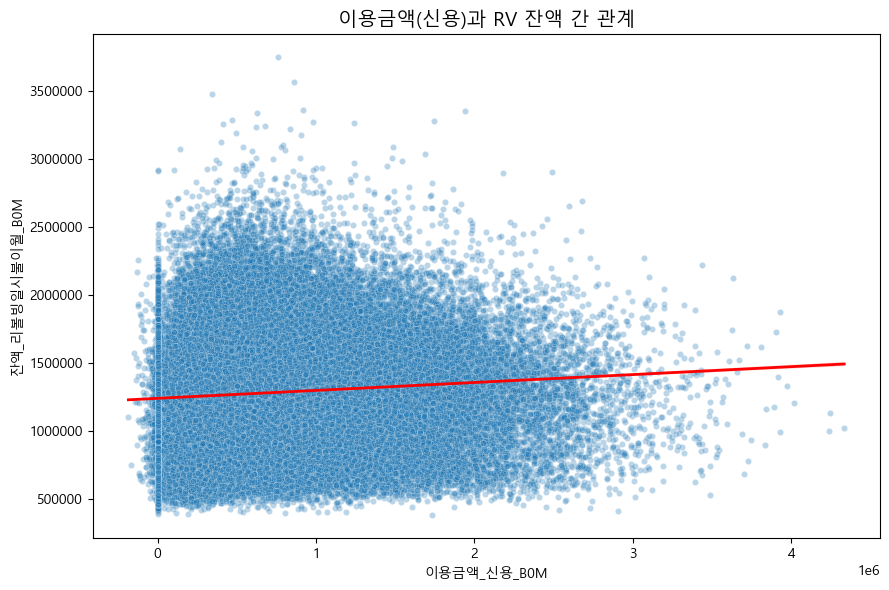

In [47]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_tmp,
    x=COL_X,
    y=COL_Y,
    alpha=0.3,
    s=20
)

# 선형 추세선(거의 평평하게 나올 가능성 큼)
sns.regplot(
    data=df_tmp,
    x=COL_X,
    y=COL_Y,
    scatter=False,
    color="red",
    line_kws={"linewidth": 2}
)

plt.title("이용금액(신용)과 RV 잔액 간 관계", fontsize=14)
plt.xlabel("이용금액_신용_B0M")
plt.ylabel("잔액_리볼빙일시불이월_B0M")

plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()


-------------------------------------------------------------------------------------------------------------------------------------------------

# RandomForest

### 1. 모든 컬럼으로 확인

In [24]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [25]:
# 데이터 로드
df = pd.read_csv("artifacts/train_data.csv")

# 타겟 설정
target_col = "잔액_리볼빙일시불이월_target"

y = df[target_col].astype(float)

# X에서 타겟 제거 후, 숫자만 남기기
X = df.drop(columns=[target_col])

if "발급회원번호" in X.columns:
    X = X.drop(columns=["발급회원번호"])

# 문자열/범주형(예: '30대') 제거 -> 숫자만 남김
X = X.select_dtypes(include=["number"])

print("X shape:", X.shape, "y shape:", y.shape)

X shape: (83403, 217) y shape: (83403,)


In [26]:
# train / test 분리

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [27]:
# RandomForest 학습

rf = RandomForestRegressor(
    n_estimators=300,   # 기본값보다 살짝만 늘림 (안정성)
    max_depth=50,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=50, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [28]:
# 예측, 평가 지표

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== RandomForest (basic) ===")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

=== RandomForest (basic) ===
MAE  : 159829.8556
RMSE : 215663.4228
R2   : 0.7786


In [29]:
# Feature Importance 확인

importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(20)

RV_평균잔액_R3M       0.56
RV_평균잔액_R6M       0.10
월중평잔_RV일시불        0.05
잔액_리볼빙일시불이월_B0M   0.03
RV_평균잔액_R12M      0.03
RV_최대잔액_R6M       0.02
평잔_RV일시불_3M       0.01
이용금액_업종기준         0.01
RV_최대잔액_R3M       0.01
RV_최대잔액_R12M      0.01
잔액_일시불_B2M        0.00
RV신청일자            0.00
잔액_일시불_B0M        0.00
이용금액_신용_B0M       0.00
잔액_일시불_B1M        0.00
RV약정청구율           0.00
최종카드발급경과월         0.00
변동률_잔액_B1M        0.00
월중평잔_일시불_B0M      0.00
변동률_잔액_일시불_B1M    0.00
dtype: float64

### 2. Boruta를 진행해서 선별된 컬럼으로 진행

In [16]:
# 잔액_일시불_B0M/B1M/B2M 평균 파생변수
inst_cols = ['잔액_일시불_B0M', '잔액_일시불_B1M', '잔액_일시불_B2M']


missing = [c for c in inst_cols if c not in df.columns]
if missing:
    raise KeyError(f"다음 컬럼이 df에 없습니다: {missing}")

df['잔액_일시불_평균_B012M'] = df[inst_cols].mean(axis=1)

selected_cols = [
    '잔액_B0M',
    'RV_평균잔액_R12M',
    '평잔_RV일시불_3M',
    '카드이용한도금액',
    '잔액_일시불_평균_B012M',
    '월중평잔_RV일시불',
    '잔액_신판평균한도소진율_r6m',
    '잔액_리볼빙일시불이월_B0M',
    'RV_최대잔액_R12M',
    '이용금액_신용_B0M'
]

target_col = '잔액_리볼빙일시불이월_target'

In [17]:
X1 = df[selected_cols]
y = df[target_col]

X1_train, X1_test, y_train, y_test = train_test_split(
    X1, y,
    test_size=0.2,
    random_state=42
)

In [19]:
rf_selected = RandomForestRegressor(
    n_estimators=300,
    max_depth=50,
    random_state=42,
    n_jobs=-1
)

rf_selected.fit(X1_train, y_train)

y_pred_1 = rf_selected.predict(X1_test)

mae_1 = mean_absolute_error(y_test, y_pred_1)
rmse_1 = np.sqrt(mean_squared_error(y_test, y_pred_1))
r2_1 = r2_score(y_test, y_pred_1)

print("=== RandomForest (selected cols) ===")
print(f"MAE  : {mae_1:.4f}")
print(f"RMSE : {rmse_1:.4f}")
print(f"R2   : {r2_1:.4f}")


=== RandomForest (selected cols) ===
MAE  : 164285.5431
RMSE : 220678.1909
R2   : 0.7681


# 결과 비교

### 1. basic    
### MAE  : 159829.8556, RMSE : 215663.4228, R2   : 0.7786


### 2. selected    
### MAE  : 164285.5431, RMSE : 220678.1909, R2   : 0.7681


# CrossValidation 진행

In [24]:
target_col = "잔액_리볼빙일시불이월_target"

X = df.drop(columns=[target_col, "발급회원번호"])
y = df[target_col]

# 숫자형만 사용
X = X.select_dtypes(include=["number"])

In [25]:
#RandomForest 모델 정의

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=50,
    random_state=42,
    n_jobs=-1
)

In [27]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_rmse = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

print("CV RMSE (각 fold):", -cv_rmse)
print("CV RMSE 평균:", -cv_rmse.mean())
print("CV RMSE 표준편차:", cv_rmse.std())

CV RMSE (각 fold): [215623.28602494 215540.27690301 217746.29075262 212717.12198939
 214916.14042123]
CV RMSE 평균: 215308.62321823527
CV RMSE 표준편차: 1610.2683307348343
